# 03 — Cálculo de \(eD_{cp}\)

Implementación de las ecuaciones (7) y (8) para **Al, Hg, Nb, Ta y Pb**. Se determinan \(\omega_\epsilon\), \(\omega_{\epsilon'}\), \(\Delta_{Dcp}\) y \(\frac12\Delta_{Dcp}\).

In [1]:
from pathlib import Path
import sys,numpy as np,pandas as pd,matplotlib.pyplot as plt

ROOT=Path.cwd().resolve()
if ROOT.name=="notebooks":
    ROOT=ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0,str(ROOT))

from src.io import (
    read_eliashberg,
    read_phonon_dos,
    read_electronic_dos
)

from src.preprocessing import (
    preprocess_eliashberg,
    preprocess_phonon_dos,
    preprocess_electronic_dos
)

# ============================================================
# MATERIALES
# ============================================================

MATERIALES = ["Al","Hg","Nb","Ta","Pb"]

# ============================================================
# TEMPERATURA CRÍTICA [K]
# ============================================================

TC_K = {
    "Al": 1.18,
    "Hg": 4.154,
    "Nb": 9.25,
    "Ta": 4.47,
    "Pb": 7.19
}

# ============================================================
# CONSTANTES
# ============================================================

kB = 8.617333262e-2       # meV/K

N_E = 1200
N_W = 500


# ============================================================
# FUNCIONES
# ============================================================

def fermi(x,b):
    z=np.clip(b*np.asarray(x),-700,700)
    return 1/(np.exp(z)+1)


def bose(w,b):
    return 0 if w<=0 else 1/np.expm1(
        np.clip(b*w,-700,700)
    )


## 1. Ecuaciones

Para \(eD_{cp}(\epsilon)\):

\[
eD_{cp}(\epsilon)=\int_0^{\omega_c}g_e^o(\epsilon)g_e^v(\epsilon-\omega)g_p^{n+1}(\omega)\left[\int g_e^o(\epsilon')g_e^v(\epsilon'+\omega)d\epsilon'\right]\alpha^2(\omega)g_p^n(\omega)d\omega.
\]

La ecuación para \(eD_{cp}(\epsilon')\) se evalúa intercambiando las variables electrónicas según la ecuación (8) de la guía.

In [2]:
# ============================================================
# Parámetros globales (ejecutar antes de calculate_edcp)
# ============================================================

N_OMEGA = 500
kB_meV_K = 8.617333262e-2  # meV/K

MATERIALES = ["Al", "Hg", "Nb", "Ta", "Pb"]

TC_K = {
    "Al": 1.18,
    "Hg": 4.154,
    "Nb": 9.25,
    "Ta": 4.47,
    "Pb": 7.19,
}

def calculate_edcp(mat):

    folder = ROOT / "data" / "raw" / mat

    # ========================================================
    # 1. CARGAR DATOS
    # ========================================================

    a = read_eliashberg(
        folder / f"{mat}_alpha2F.csv"
    )

    ph = read_phonon_dos(
        folder / f"{mat}_DOS_fonones.csv"
    )

    el = read_electronic_dos(
        folder / f"{mat}_DOS_electronica.csv"
    )

    # ========================================================
    # 2. ELIASHBERG
    # ========================================================

    try:

        eli = preprocess_eliashberg(
            a["frequency_mev"],
            a["a2f_total"]
        )

        wc = float(
            eli["omega_c_mev"]
        )

    except ValueError as err:

        if "No se encontró un punto con alpha^2F = 0" not in str(err):
            raise

        freq = np.asarray(
            a["frequency_mev"],
            dtype=float
        )

        a2f_raw = np.asarray(
            a["a2f_total"],
            dtype=float
        )

        mask = (
            np.isfinite(freq)
            & np.isfinite(a2f_raw)
            & (freq >= 0.0)
            & (a2f_raw >= 0.0)
        )

        freq = freq[mask]
        a2f_raw = a2f_raw[mask]

        if freq.size == 0:
            raise ValueError(
                f"{mat}: sin datos válidos de Eliashberg."
            )

        order = np.argsort(freq)

        freq = freq[order]
        a2f_raw = a2f_raw[order]

        wc = float(freq[-1])

        eli = {
            "frequency_mev": freq,
            "a2f_total": a2f_raw,
            "omega_c_mev": wc,
        }

    # ========================================================
    # 3. DOS DE FONONES
    # ========================================================

    p = preprocess_phonon_dos(
        ph["frequency_mev"],
        ph["dos"],
        omega_c_mev=wc,
    )

    # ========================================================
    # 4. DATOS ELECTRÓNICOS CRUDOS
    # ========================================================

    eps_raw = np.asarray(
        el["epsilon_mev"],
        dtype=float
    )

    dos_raw = np.asarray(
        el["dos"],
        dtype=float
    )

    mask = (
        np.isfinite(eps_raw)
        & np.isfinite(dos_raw)
    )

    eps_raw = eps_raw[mask]
    dos_raw = dos_raw[mask]

    if eps_raw.size < 2:
        raise ValueError(
            f"{mat}: DOS electrónico insuficiente."
        )

    # El DOS no puede ser negativo
    dos_raw = np.maximum(
        dos_raw,
        0.0
    )

    # Ordenar
    order = np.argsort(
        eps_raw
    )

    eps_raw = eps_raw[order]
    dos_raw = dos_raw[order]

    # Eliminar energías repetidas
    eps_raw, idx = np.unique(
        eps_raw,
        return_index=True
    )

    dos_raw = dos_raw[idx]

    # ========================================================
    # 5. MALLA ELECTRÓNICA FÍSICA
    #
    # Ahora sí trabajamos exclusivamente en
    #
    #       -omega_c <= epsilon <= omega_c
    #
    # ========================================================

    epsilon = np.linspace(
        -wc,
        wc,
        N_E
    )

    # Interpolar DOS sobre la nueva malla
    Ne_grid = np.interp(
        epsilon,
        eps_raw,
        dos_raw,
        left=0.0,
        right=0.0
    )

    # ========================================================
    # 6. NORMALIZAR DOS ELECTRÓNICO
    # ========================================================

    Ne_max = np.max(
        Ne_grid
    )

    if Ne_max <= 0.0:

        raise ValueError(
            f"{mat}: DOS electrónico nulo dentro "
            "de la ventana ±omega_c."
        )

    Ne_grid = (
        Ne_grid
        / Ne_max
    )

    # ========================================================
    # 7. MALLA FÓNONICA
    # ========================================================

    omega = np.linspace(
        0.0,
        wc,
        N_OMEGA
    )

    # ========================================================
    # 8. alpha^2 F
    # ========================================================

    a2f = np.interp(
        omega,
        eli["frequency_mev"],
        eli["a2f_total"],
        left=0.0,
        right=0.0
    )

    a2f = np.maximum(
        a2f,
        0.0
    )

    # ========================================================
    # 9. DOS DE FONONES
    # ========================================================

    nph = np.interp(
        omega,
        p["frequency_mev"],
        p["dos"],
        left=0.0,
        right=0.0
    )

    nph = np.maximum(
        nph,
        0.0
    )

    # ========================================================
    # 10. TEMPERATURA
    # ========================================================

    beta = 1.0 / (
        kB_meV_K
        * TC_K[mat]
    )

    # ========================================================
    # 11. DISTRIBUCIÓN DE FERMI
    # ========================================================

    def fermi(x):

        x = np.asarray(
            x,
            dtype=float
        )

        z = np.clip(
            beta * x,
            -700.0,
            700.0
        )

        return (
            1.0
            /
            (
                np.exp(z)
                + 1.0
            )
        )

    # ========================================================
    # 12. DISTRIBUCIÓN DE BOSE
    # ========================================================

    def bose(w):

        if w <= 0.0:
            return 0.0

        z = np.clip(
            beta * w,
            -700.0,
            700.0
        )

        return 1.0 / np.expm1(z)

    # ========================================================
    # 13. INTERPOLADOR DEL DOS ELECTRÓNICO
    # ========================================================

    def Ne(x):

        x = np.asarray(
            x,
            dtype=float
        )

        return np.interp(
            x,
            epsilon,
            Ne_grid,
            left=0.0,
            right=0.0
        )

    # ========================================================
    # 14. g_e^o(epsilon)
    #
    # g_e^o = N_e f
    # ========================================================

    f_eps = fermi(
        epsilon
    )

    ge_o = (
        Ne_grid
        * f_eps
    )

    # ========================================================
    # 15. INTEGRALES INTERNAS
    #
    # Ecuación (7):
    #
    # I_plus(w) =
    #
    # ∫ g_e^o(epsilon')
    #   g_e^v(epsilon' + w)
    #   d epsilon'
    #
    # ========================================================

    I_plus = np.zeros_like(
        omega
    )

    # ========================================================
    # Ecuación (8):
    #
    # I_minus(w) =
    #
    # ∫ g_e^o(epsilon)
    #   g_e^v(epsilon - w)
    #   d epsilon
    #
    # ========================================================

    I_minus = np.zeros_like(
        omega
    )

    for j, w in enumerate(omega):

        if w <= 0.0:
            continue

        # ----------------------------------------------------
        # epsilon + omega
        # ----------------------------------------------------

        ep_plus = (
            epsilon
            + w
        )

        Ne_plus = Ne(
            ep_plus
        )

        f_plus = fermi(
            ep_plus
        )

        ge_v_plus = (
            Ne_plus
            * (1.0 - f_plus)
        )

        # ----------------------------------------------------
        # epsilon - omega
        # ----------------------------------------------------

        ep_minus = (
            epsilon
            - w
        )

        Ne_minus = Ne(
            ep_minus
        )

        f_minus = fermi(
            ep_minus
        )

        ge_v_minus = (
            Ne_minus
            * (1.0 - f_minus)
        )

        # ----------------------------------------------------
        # Integrales
        # ----------------------------------------------------

        I_plus[j] = np.trapezoid(
            ge_o
            * ge_v_plus,
            epsilon
        )

        I_minus[j] = np.trapezoid(
            ge_o
            * ge_v_minus,
            epsilon
        )

    # ========================================================
    # 16. FACTOR FONÓNICO
    #
    # alpha^2 g_p^(n+1) g_p^n
    #
    # = alpha^2 F N_ph n(n+1)
    #
    # ========================================================

    phonon_factor = np.zeros_like(
        omega
    )

    for j, w in enumerate(omega):

        if w <= 0.0:
            continue

        n = bose(
            w
        )

        phonon_factor[j] = (
            a2f[j]
            * nph[j]
            * n
            * (n + 1.0)
        )

    # ========================================================
    # 17. eDcp(epsilon)
    #
    # ECUACIÓN (7)
    #
    # ========================================================

    eDcp_eps = np.zeros_like(
        epsilon
    )

    for i, eps0 in enumerate(epsilon):

        # g_e^o(epsilon)
        go0 = ge_o[i]

        if go0 <= 0.0:
            continue

        values = np.zeros_like(
            omega
        )

        for j, w in enumerate(omega):

            if w <= 0.0:
                continue

            # ------------------------------------------------
            # g_e^v(epsilon - omega)
            # ------------------------------------------------

            eps_minus = (
                eps0
                - w
            )

            Ne_minus = Ne(
                eps_minus
            )

            f_minus = fermi(
                eps_minus
            )

            ge_v_minus = (
                Ne_minus
                * (1.0 - f_minus)
            )

            # ------------------------------------------------
            # Ecuación (7)
            # ------------------------------------------------

            values[j] = (
                go0
                * ge_v_minus
                * I_plus[j]
                * phonon_factor[j]
            )

        eDcp_eps[i] = np.trapezoid(
            values,
            omega
        )

    # ========================================================
    # 18. eDcp(epsilon')
    #
    # ECUACIÓN (8)
    #
    # ========================================================

    eDcp_epsp = np.zeros_like(
        epsilon
    )

    for i, epsp0 in enumerate(epsilon):

        # g_e^o(epsilon')
        go0 = ge_o[i]

        if go0 <= 0.0:
            continue

        values = np.zeros_like(
            omega
        )

        for j, w in enumerate(omega):

            if w <= 0.0:
                continue

            # ------------------------------------------------
            # g_e^v(epsilon' + omega)
            # ------------------------------------------------

            eps_plus = (
                epsp0
                + w
            )

            Ne_plus = Ne(
                eps_plus
            )

            f_plus = fermi(
                eps_plus
            )

            ge_v_plus = (
                Ne_plus
                * (1.0 - f_plus)
            )

            # ------------------------------------------------
            # Ecuación (8)
            # ------------------------------------------------

            values[j] = (
                go0
                * ge_v_plus
                * I_minus[j]
                * phonon_factor[j]
            )

        eDcp_epsp[i] = np.trapezoid(
            values,
            omega
        )

    # ========================================================
    # 19. MÁXIMOS
    # ========================================================

    i_eps = int(
        np.argmax(
            eDcp_eps
        )
    )

    i_epsp = int(
        np.argmax(
            eDcp_epsp
        )
    )

    omega_epsilon = float(
        epsilon[i_eps]
    )

    omega_epsilon_prime = float(
        epsilon[i_epsp]
    )

    # ========================================================
    # 20. DELTA_DCP
    # ========================================================

    Delta_Dcp = float(
        abs(
            omega_epsilon
            - omega_epsilon_prime
        )
    )

    half_Delta_Dcp = (
        0.5
        * Delta_Dcp
    )

    # ========================================================
    # 21. DIAGNÓSTICOS
    # ========================================================

    print(
        f"\n{mat} eDcp:"
    )

    print(
        f"  Tc = {TC_K[mat]:.4f} K"
    )

    print(
        f"  omega_c = {wc:.6f} meV"
    )

    print(
        f"  ventana epsilon = "
        f"[{epsilon.min():.6f}, "
        f"{epsilon.max():.6f}] meV"
    )

    print(
        f"  max Ne = "
        f"{Ne_grid.max():.6e}"
    )

    print(
        f"  max g_e^o = "
        f"{ge_o.max():.6e}"
    )

    print(
        f"  max I_plus = "
        f"{I_plus.max():.6e}"
    )

    print(
        f"  max I_minus = "
        f"{I_minus.max():.6e}"
    )

    print(
        f"  max phonon_factor = "
        f"{phonon_factor.max():.6e}"
    )

    print(
        f"  max eDcp(epsilon) = "
        f"{eDcp_eps.max():.6e}"
    )

    print(
        f"  max eDcp(epsilon') = "
        f"{eDcp_epsp.max():.6e}"
    )

    print(
        f"  omega_epsilon = "
        f"{omega_epsilon:.6f} meV"
    )

    print(
        f"  omega_epsilon' = "
        f"{omega_epsilon_prime:.6f} meV"
    )

    print(
        f"  Delta_Dcp = "
        f"{Delta_Dcp:.6f} meV"
    )

    print(
        f"  1/2 Delta_Dcp = "
        f"{half_Delta_Dcp:.6f} meV"
    )

    # ========================================================
    # 22. RESULTADO
    # ========================================================

    return {

        "material": mat,

        "Tc_K": TC_K[mat],

        "omega_c": wc,

        "omega": omega,

        "epsilon": epsilon,

        "edcp_epsilon": eDcp_eps,

        "edcp_epsilon_prime": eDcp_epsp,

        "omega_epsilon": omega_epsilon,

        "omega_epsilon_prime": omega_epsilon_prime,

        "Delta_Dcp": Delta_Dcp,

        "half_Delta_Dcp": half_Delta_Dcp,

        "a2f_grid": a2f,

        "nph_grid": nph,

        "phonon_factor": phonon_factor,

        "alpha2_grid": np.divide(
            a2f,
            nph,
            out=np.zeros_like(a2f),
            where=nph > 0.0
        ),

        "I_plus": I_plus,

        "I_minus": I_minus,

        "ne_grid": Ne_grid,
    }

In [3]:
results = {}

for mat in MATERIALES:

    out = calculate_edcp(mat)

    results[mat] = out

    print(
        f"{mat}: "
        f"omega_epsilon={out['omega_epsilon']:.4f} meV | "
        f"omega_epsilon'={out['omega_epsilon_prime']:.4f} meV | "
        f"Delta_Dcp={out['Delta_Dcp']:.4f} meV | "
        f"1/2 Delta_Dcp={out['half_Delta_Dcp']:.4f} meV"
    )


Al eDcp:
  Tc = 1.1800 K
  omega_c = 39.676242 meV
  ventana epsilon = [-39.676242, 39.676242] meV
  max Ne = 1.000000e+00
  max g_e^o = 1.000000e+00
  max I_plus = 3.807484e+01
  max I_minus = 6.457027e-02
  max phonon_factor = 1.648816e-14
  max eDcp(epsilon) = 3.552791e-17
  max eDcp(epsilon') = 3.552732e-17
  omega_epsilon = 0.165456 meV
  omega_epsilon' = -0.165456 meV
  Delta_Dcp = 0.330911 meV
  1/2 Delta_Dcp = 0.165456 meV
Al: omega_epsilon=0.1655 meV | omega_epsilon'=-0.1655 meV | Delta_Dcp=0.3309 meV | 1/2 Delta_Dcp=0.1655 meV

Hg eDcp:
  Tc = 4.1540 K
  omega_c = 11.342195 meV
  ventana epsilon = [-11.342195, 11.342195] meV
  max Ne = 1.000000e+00
  max g_e^o = 9.650563e-01
  max I_plus = 1.029740e+01
  max I_minus = 3.276433e-01
  max phonon_factor = 1.003441e-03
  max eDcp(epsilon) = 1.495559e-05
  max eDcp(epsilon') = 1.496959e-05
  omega_epsilon = 0.425687 meV
  omega_epsilon' = -0.425687 meV
  Delta_Dcp = 0.851374 meV
  1/2 Delta_Dcp = 0.425687 meV
Hg: omega_epsilon=0.

## 2. Gráficas y exportación

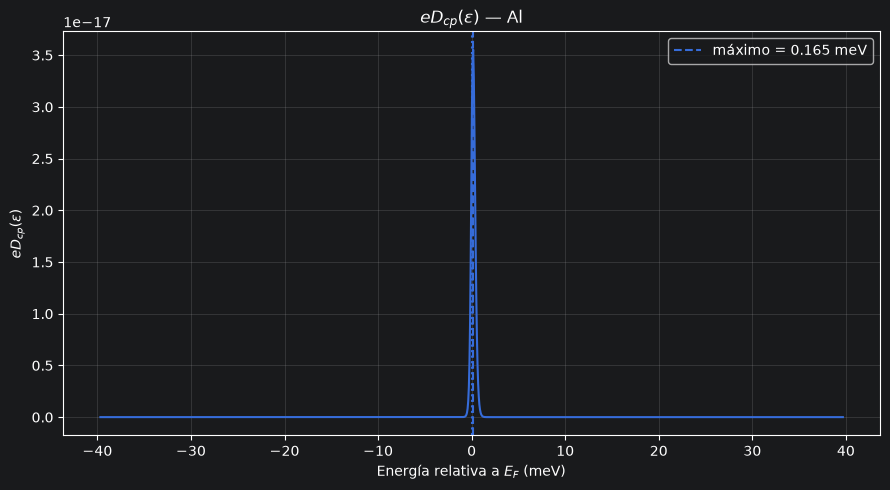

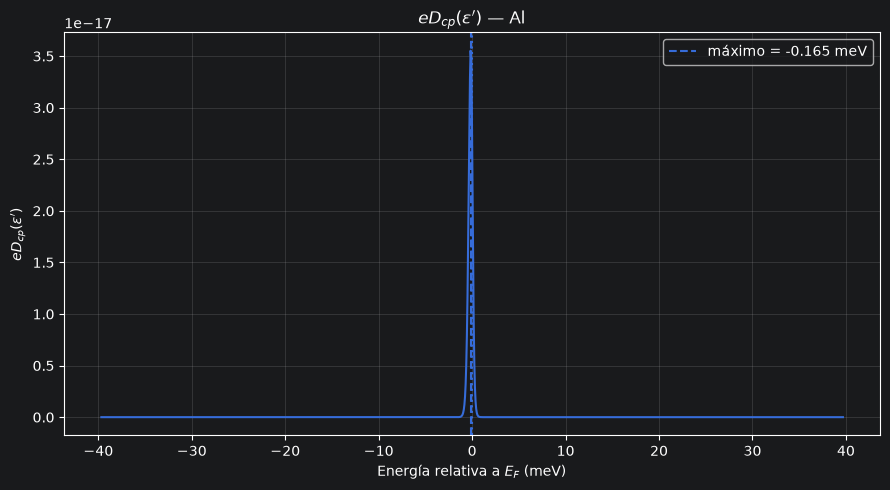

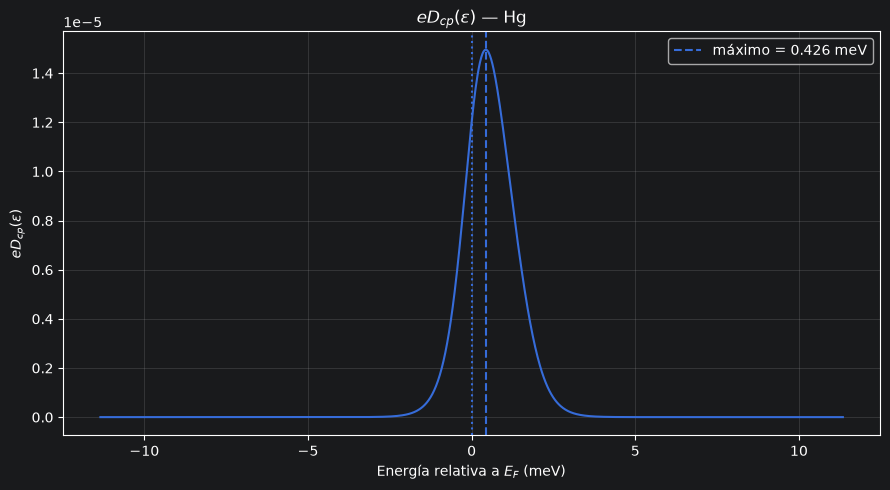

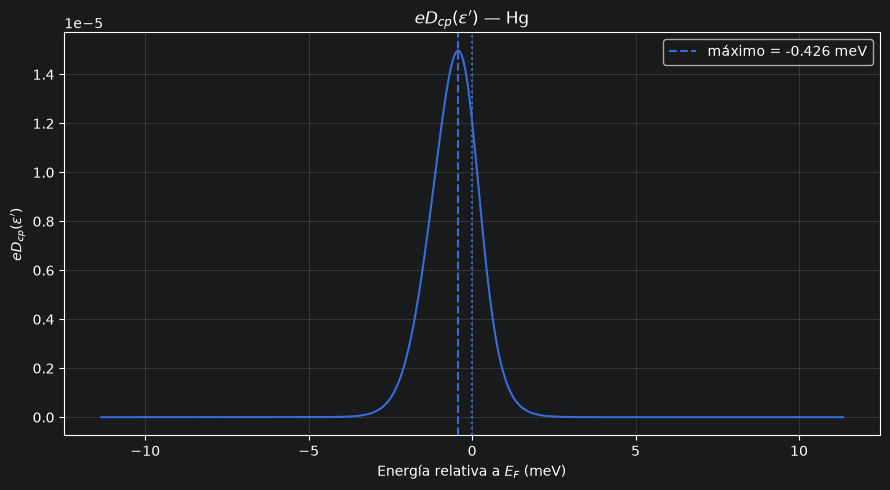

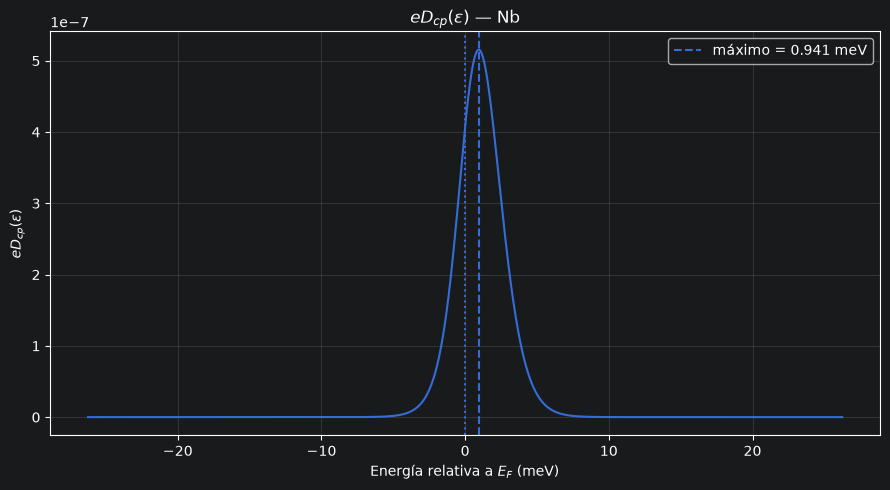

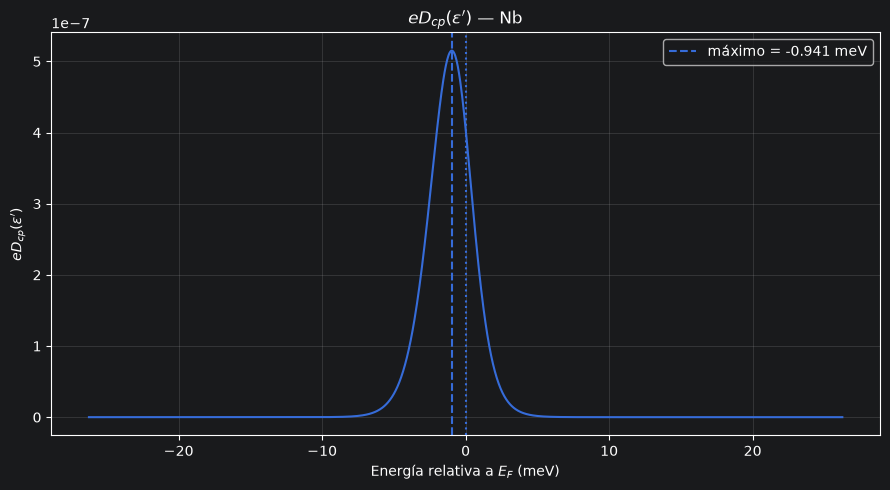

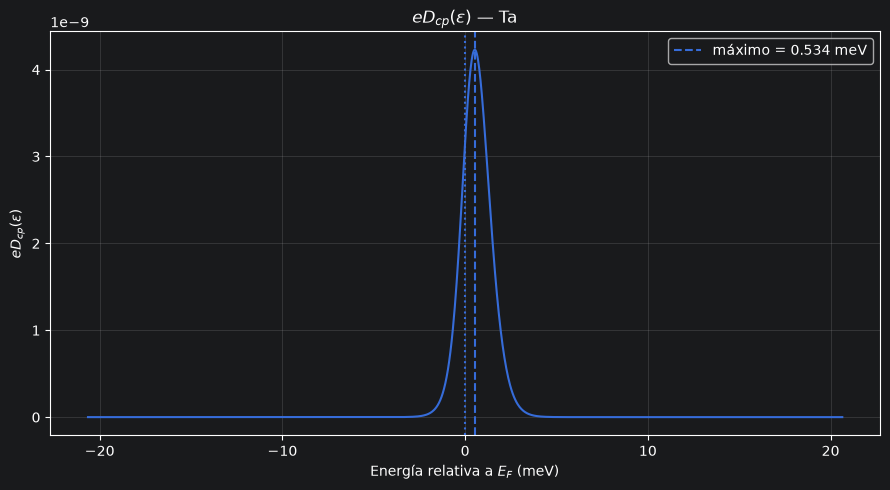

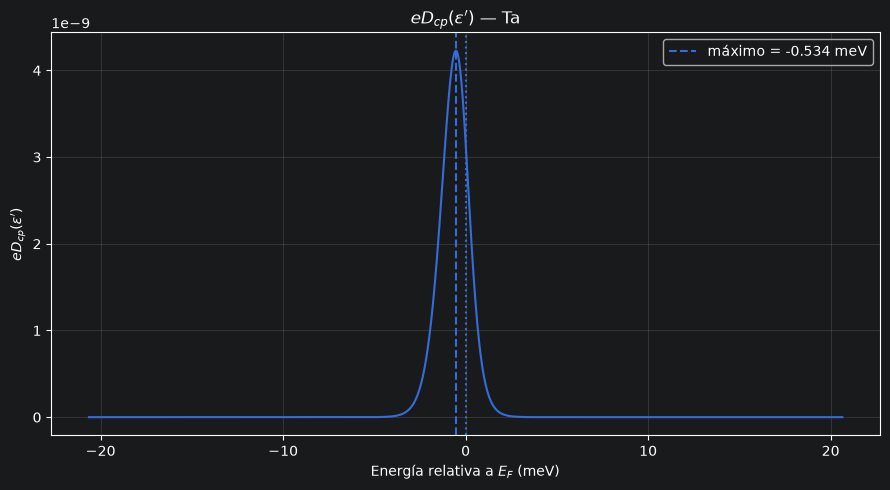

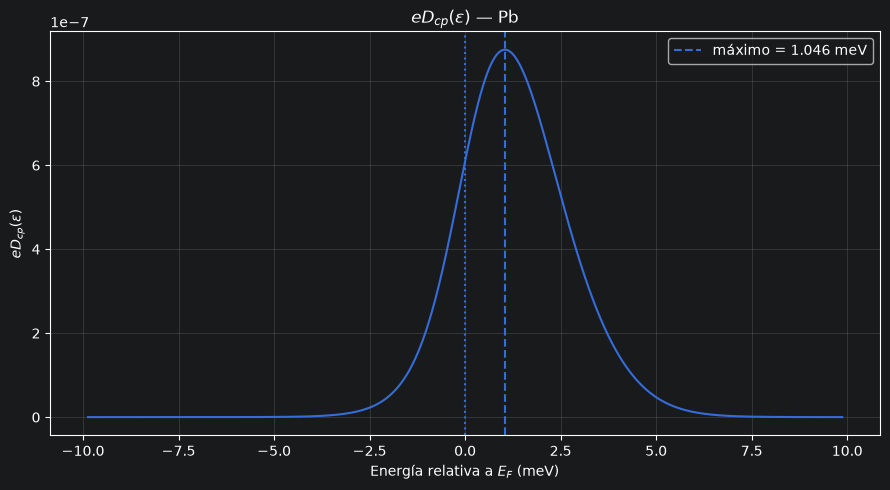

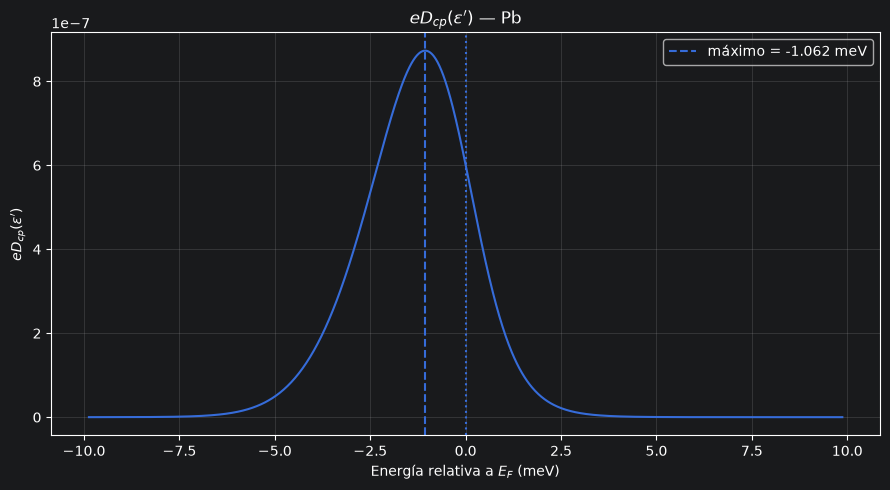

,material,Tc_K,omega_c_meV,omega_epsilon_meV,omega_epsilon_prime_meV,Delta_Dcp_meV,half_Delta_Dcp_meV
0,Al,1.180,39.676242,0.165456,-0.165456,0.330911,0.165456
1,Hg,4.154,11.342195,0.425687,-0.425687,0.851374,0.425687
2,Nb,9.250,26.248375,0.941351,-0.941351,1.882702,0.941351
3,Ta,4.470,20.639428,0.533630,-0.533630,1.067260,0.533630
4,Pb,7.190,9.870604,1.045510,-1.061975,2.107485,1.053743


In [4]:
TABLES = ROOT / "results" / "tables"
FIGS = ROOT / "results" / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

summary = []

for mat, r in results.items():
    if not isinstance(r, dict):
        continue

    # Si todavía está en modo placeholder, saltar sin romper
    needed_plot = {"epsilon", "edcp_epsilon", "edcp_epsilon_prime", "omega_epsilon", "omega_epsilon_prime"}
    if not needed_plot.issubset(r.keys()):
        print(f"{mat}: salida incompleta, se omite export de eDcp detallado.")
        summary.append({
            "material": r.get("material", mat),
            "Tc_K": r.get("Tc_K", np.nan),
            "omega_c_meV": r.get("omega_c_mev", np.nan),
        })
        continue

    for key, label, peak in [
        ("edcp_epsilon", r"$eD_{cp}(\epsilon)$", r["omega_epsilon"]),
        ("edcp_epsilon_prime", r"$eD_{cp}(\epsilon')$", r["omega_epsilon_prime"]),
    ]:
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(r["epsilon"], r[key])
        ax.axvline(peak, ls="--", label=f"máximo = {peak:.3f} meV")
        ax.axvline(0, ls=":")
        ax.set(
            xlabel="Energía relativa a $E_F$ (meV)",
            ylabel=label,
            title=f"{label} — {mat}",
        )
        ax.grid(alpha=.25)
        ax.legend()
        fig.tight_layout()
        fig.savefig(FIGS / f"{mat}_{key}.png", dpi=300)
        plt.show()

    pd.DataFrame({
        "epsilon_meV": r["epsilon"],
        "eDcp_epsilon": r["edcp_epsilon"],
        "eDcp_epsilon_prime": r["edcp_epsilon_prime"],
    }).to_csv(TABLES / f"{mat}_eDcp.csv", index=False)

    summary.append({
        "material": r["material"],
        "Tc_K": r["Tc_K"],
        "omega_c_meV": r["omega_c"],
        "omega_epsilon_meV": r["omega_epsilon"],
        "omega_epsilon_prime_meV": r["omega_epsilon_prime"],
        "Delta_Dcp_meV": r["Delta_Dcp"],
        "half_Delta_Dcp_meV": r["half_Delta_Dcp"],
    })

summary_df = pd.DataFrame(summary)
summary_df.to_csv(TABLES / "eDcp_resumen.csv", index=False)
display(summary_df)

## 3. Diagnóstico

Los máximos se extraen directamente de la malla numérica. La comparación con \(\Delta(0)\) se realiza en el notebook 04.